# Análisis Exploratorio de Datos (EDA) — Dataset Titanic
**TC2004B — Análisis y Ciencia de Datos**

---

> **Dataset fuente:** Titanic passenger data — datos abiertos disponibles en [OpenML #40945](https://www.openml.org/d/40945)  
> **Acceso programático:** `seaborn.load_dataset('titanic')` (licencia pública, uso educativo)

---

## 0. Configuración del entorno

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
FIGSIZE_WIDE = (14, 5)
COLOR_POS    = '#2ecc71'
COLOR_NEG    = '#e74c3c'
COLOR_NEUT   = '#3498db'

print('Librerías cargadas correctamente ✓')

Librerías cargadas correctamente ✓


---
## 1. Contexto del Dataset

### ¿Qué es?
El **RMS Titanic** se hundió el 15 de abril de 1912 tras chocar con un iceberg.  
De las **2,224 personas a bordo** (pasajeros + tripulación), sobrevivieron aproximadamente **710 (~32%)**.  
Este dataset contiene información de **891 pasajeros** (muestra representativa del manifiesto de pasaje).

### Variables clave

| Variable | Tipo | Descripción |
|----------|------|-------------|
| `survived` | Binaria (0/1) | **Variable objetivo** — 1 = sobrevivió |
| `pclass` | Ordinal (1,2,3) | Clase del camarote (1ª, 2ª, 3ª) |
| `sex` | Categórica | Sexo del pasajero |
| `age` | Numérica continua | Edad en años |
| `sibsp` | Numérica discreta | # hermanos/cónyuge a bordo |
| `parch` | Numérica discreta | # padres/hijos a bordo |
| `fare` | Numérica continua | Tarifa pagada (libras esterlinas 1912) |
| `embarked` | Categórica | Puerto de embarque: C=Cherburgo, Q=Queenstown, S=Southampton |
| `deck` | Ordinal (A–G) | Cubierta del camarote |

### ¿Por qué es relevante?
Es un caso histórico real donde la supervivencia dependió de **factores socioeconómicos, demográficos y logísticos** — ideal para explorar relaciones entre variables y desigualdad de acceso a recursos de emergencia.

In [2]:
df = sns.load_dataset('titanic')
print(f'Dimensiones: {df.shape[0]} filas × {df.shape[1]} columnas')
print('\nPrimeras 5 filas:')
df.head()

Dimensiones: 891 filas × 15 columnas

Primeras 5 filas:


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.00,1,0,7.25,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.00,1,0,71.28,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.00,0,0,7.92,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.00,1,0,53.10,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.00,0,0,8.05,S,Third,man,True,NaN,Southampton,no,True


In [3]:
print('Tipos de datos por columna:')
print(df.dtypes.to_string())
print(f'\nVariables numéricas  : {df.select_dtypes(include=np.number).columns.tolist()}')
print(f'Variables categóricas: {df.select_dtypes(include=["object","category","bool"]).columns.tolist()}')

Tipos de datos por columna:
survived          int64
pclass            int64
sex                 str
age             float64
sibsp             int64
parch             int64
fare            float64
embarked            str
class          category
who                 str
adult_male         bool
deck           category
embark_town         str
alive               str
alone              bool

Variables numéricas  : ['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare']
Variables categóricas: ['sex', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']


---
## 2. Calidad de Datos

### 2.1 Valores faltantes

Columnas con valores faltantes:


,Nulos,% Faltante
deck,688,77.22
age,177,19.87
embarked,2,0.22
embark_town,2,0.22


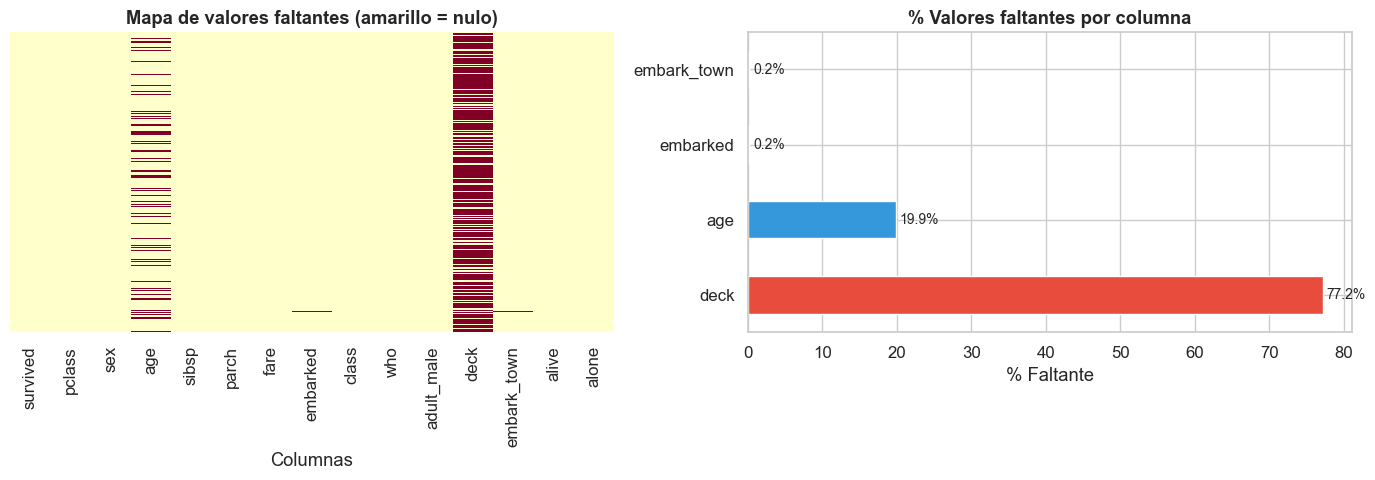

In [4]:
missing = pd.DataFrame({
    'Nulos'      : df.isnull().sum(),
    '% Faltante' : (df.isnull().sum() / len(df) * 100).round(2)
}).sort_values('% Faltante', ascending=False)
missing = missing[missing['Nulos'] > 0]

print('Columnas con valores faltantes:')
from IPython.display import display
display(missing)

fig, axes = plt.subplots(1, 2, figsize=FIGSIZE_WIDE)

sns.heatmap(df.isnull(), cbar=False, yticklabels=False,
            cmap='YlOrRd', ax=axes[0])
axes[0].set_title('Mapa de valores faltantes (amarillo = nulo)', fontweight='bold')
axes[0].set_xlabel('Columnas')

bar_colors = [COLOR_NEG if x > 50 else COLOR_NEUT for x in missing['% Faltante']]
missing['% Faltante'].plot(kind='barh', ax=axes[1], color=bar_colors)
axes[1].set_title('% Valores faltantes por columna', fontweight='bold')
axes[1].set_xlabel('% Faltante')
for i, v in enumerate(missing['% Faltante']):
    axes[1].text(v + 0.5, i, f'{v:.1f}%', va='center', fontsize=10)

plt.tight_layout()
plt.show()

#### Diagnóstico de valores faltantes

| Columna | % Faltante | Estrategia recomendada |
|---------|-----------|------------------------|
| `deck` | ~77% | **Descartar** — demasiada pérdida de información para imputar con confianza |
| `age` | ~20% | **Imputar con mediana por `pclass` y `sex`** — variables correlacionadas con edad |
| `embarked` | <1% (2 obs.) | **Imputar con moda** (Southampton es el más frecuente) |

### 2.2 Duplicados

In [5]:
n_dup = df.duplicated().sum()
print(f'Filas duplicadas exactas: {n_dup}')
if n_dup == 0:
    print('→ Sin duplicados. Dataset limpio en este aspecto.')
else:
    print(f'→ Se recomienda eliminar {n_dup} fila(s) duplicadas.')

Filas duplicadas exactas: 107
→ Se recomienda eliminar 107 fila(s) duplicadas.


### 2.3 Rangos anómalos y valores atípicos

=== Estadísticas descriptivas (variables numéricas clave) ===


,count,mean,std,min,25%,50%,75%,max
age,714.00,29.70,14.53,0.42,20.12,28.00,38.00,80.00
fare,891.00,32.20,49.69,0.00,7.91,14.45,31.00,512.33
sibsp,891.00,0.52,1.10,0.00,0.00,0.00,1.00,8.00
parch,891.00,0.38,0.81,0.00,0.00,0.00,0.00,6.00


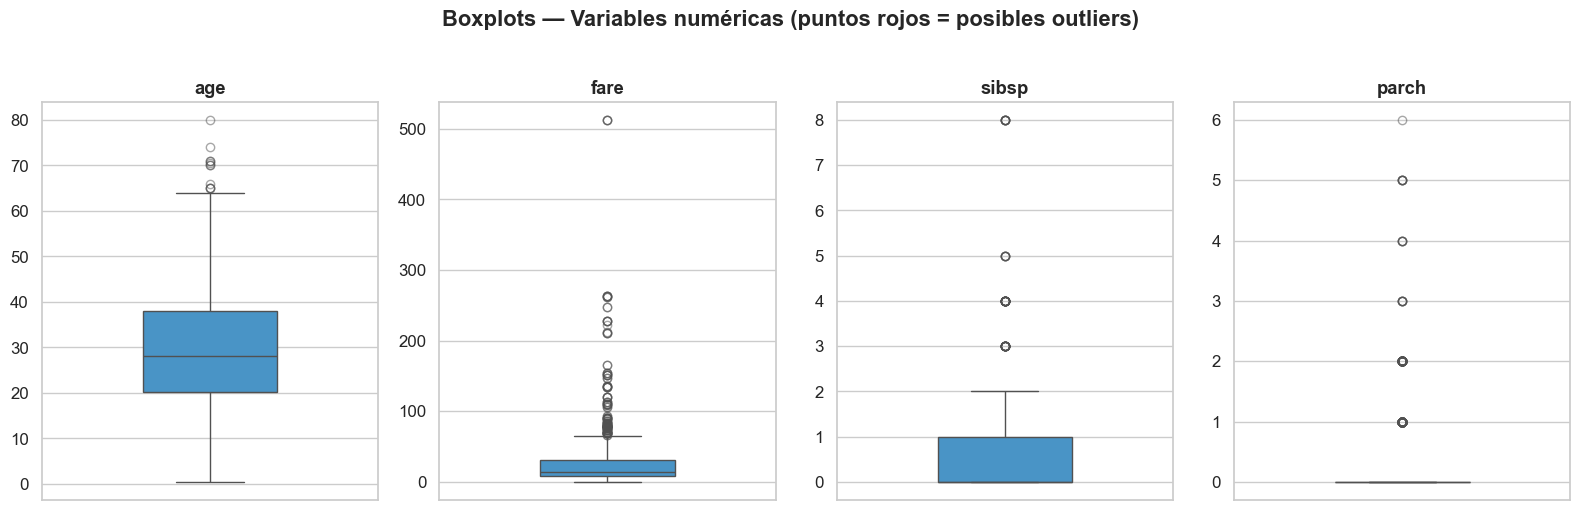

Tarifas = £0  : 15 pasajeros (posible error o tripulación)
Edad > 70     : 5 pasajeros
Fare > £300   : 3 pasajeros (suites 1ª clase)

Pasajeros con fare = £0:


,pclass,sex,age,fare,embarked
179,3,male,36.00,0.00,S
263,1,male,40.00,0.00,S
271,3,male,25.00,0.00,S
277,2,male,NaN,0.00,S
302,3,male,19.00,0.00,S
413,2,male,NaN,0.00,S
466,2,male,NaN,0.00,S
481,2,male,NaN,0.00,S
597,3,male,49.00,0.00,S
633,1,male,NaN,0.00,S


In [6]:
num_cols = ['age', 'fare', 'sibsp', 'parch']
print('=== Estadísticas descriptivas (variables numéricas clave) ===')
display(df[num_cols].describe().T)

fig, axes = plt.subplots(1, 4, figsize=(16, 5))
for ax, col in zip(axes, num_cols):
    sns.boxplot(y=df[col], ax=ax, color=COLOR_NEUT, width=0.4,
                flierprops=dict(marker='o', color=COLOR_NEG, alpha=0.5))
    ax.set_title(col, fontweight='bold')
    ax.set_ylabel('')

plt.suptitle('Boxplots — Variables numéricas (puntos rojos = posibles outliers)',
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f'Tarifas = £0  : {(df["fare"] == 0).sum()} pasajeros (posible error o tripulación)')
print(f'Edad > 70     : {(df["age"] > 70).sum()} pasajeros')
print(f'Fare > £300   : {(df["fare"] > 300).sum()} pasajeros (suites 1ª clase)')
print(f'\nPasajeros con fare = £0:')
display(df[df['fare'] == 0][['pclass','sex','age','fare','embarked']].head(10))

#### Diagnóstico de rangos

| Hallazgo | Posible causa | Acción |
|----------|---------------|--------|
| `fare = 0` (15 pasajeros) | Tripulación embarcada o errores de registro | Investigar; posible exclusión o flag especial |
| `fare > 300` (3 pasajeros) | Suites de primera clase con múltiples habitaciones | Legítimos — conservar |
| `age` con valores fraccionarios | Bebés menores de 1 año (ej. 0.42 = ~5 meses) | Legítimos — conservar |
| `sibsp/parch` altos (ej. sibsp=8) | Familias muy numerosas | Verificar consistencia con otros registros |

---
## 3. Métricas Básicas

In [7]:
print('=== ESTADÍSTICAS DESCRIPTIVAS — Numéricas ===')
display(df.describe().T)

print('\n=== FRECUENCIAS — Categóricas ===')
for col in ['pclass', 'sex', 'embarked']:
    print(f'\n--- {col} ---')
    freq = df[col].value_counts(dropna=False)
    pct  = df[col].value_counts(dropna=False, normalize=True).mul(100).round(1)
    display(pd.concat([freq.rename('Conteo'), pct.rename('%')], axis=1))

=== ESTADÍSTICAS DESCRIPTIVAS — Numéricas ===


,count,mean,std,min,25%,50%,75%,max
survived,891.00,0.38,0.49,0.00,0.00,0.00,1.00,1.00
pclass,891.00,2.31,0.84,1.00,2.00,3.00,3.00,3.00
age,714.00,29.70,14.53,0.42,20.12,28.00,38.00,80.00
sibsp,891.00,0.52,1.10,0.00,0.00,0.00,1.00,8.00
parch,891.00,0.38,0.81,0.00,0.00,0.00,0.00,6.00
fare,891.00,32.20,49.69,0.00,7.91,14.45,31.00,512.33



=== FRECUENCIAS — Categóricas ===

--- pclass ---


,Conteo,%
pclass,,
3,491,55.10
1,216,24.20
2,184,20.70



--- sex ---


,Conteo,%
sex,,
male,577,64.80
female,314,35.20



--- embarked ---


,Conteo,%
embarked,,
S,644,72.30
C,168,18.90
Q,77,8.60
NaN,2,0.20


In [8]:
surv_rate = df['survived'].mean()
print('===== MÉTRICAS CLAVE =====')
print(f'Total pasajeros          : {len(df):>6}')
print(f'Sobrevivientes           : {df["survived"].sum():>6}  ({surv_rate*100:.1f}%)')
print(f'No sobrevivientes        : {(df["survived"]==0).sum():>6}  ({(1-surv_rate)*100:.1f}%)')
print(f'Edad promedio            : {df["age"].mean():>6.1f} años')
print(f'Mediana edad             : {df["age"].median():>6.1f} años')
print(f'Tarifa promedio          : £{df["fare"].mean():>6.2f}')
print(f'Tarifa mediana           : £{df["fare"].median():>6.2f}')
print(f'% Mujeres                : {(df["sex"]=="female").mean()*100:>6.1f}%')
print(f'% Pasajeros en 3ª clase  : {(df["pclass"]==3).mean()*100:>6.1f}%')

===== MÉTRICAS CLAVE =====
Total pasajeros          :    891
Sobrevivientes           :    342  (38.4%)
No sobrevivientes        :    549  (61.6%)
Edad promedio            :   29.7 años
Mediana edad             :   28.0 años
Tarifa promedio          : £ 32.20
Tarifa mediana           : £ 14.45
% Mujeres                :   35.2%
% Pasajeros en 3ª clase  :   55.1%


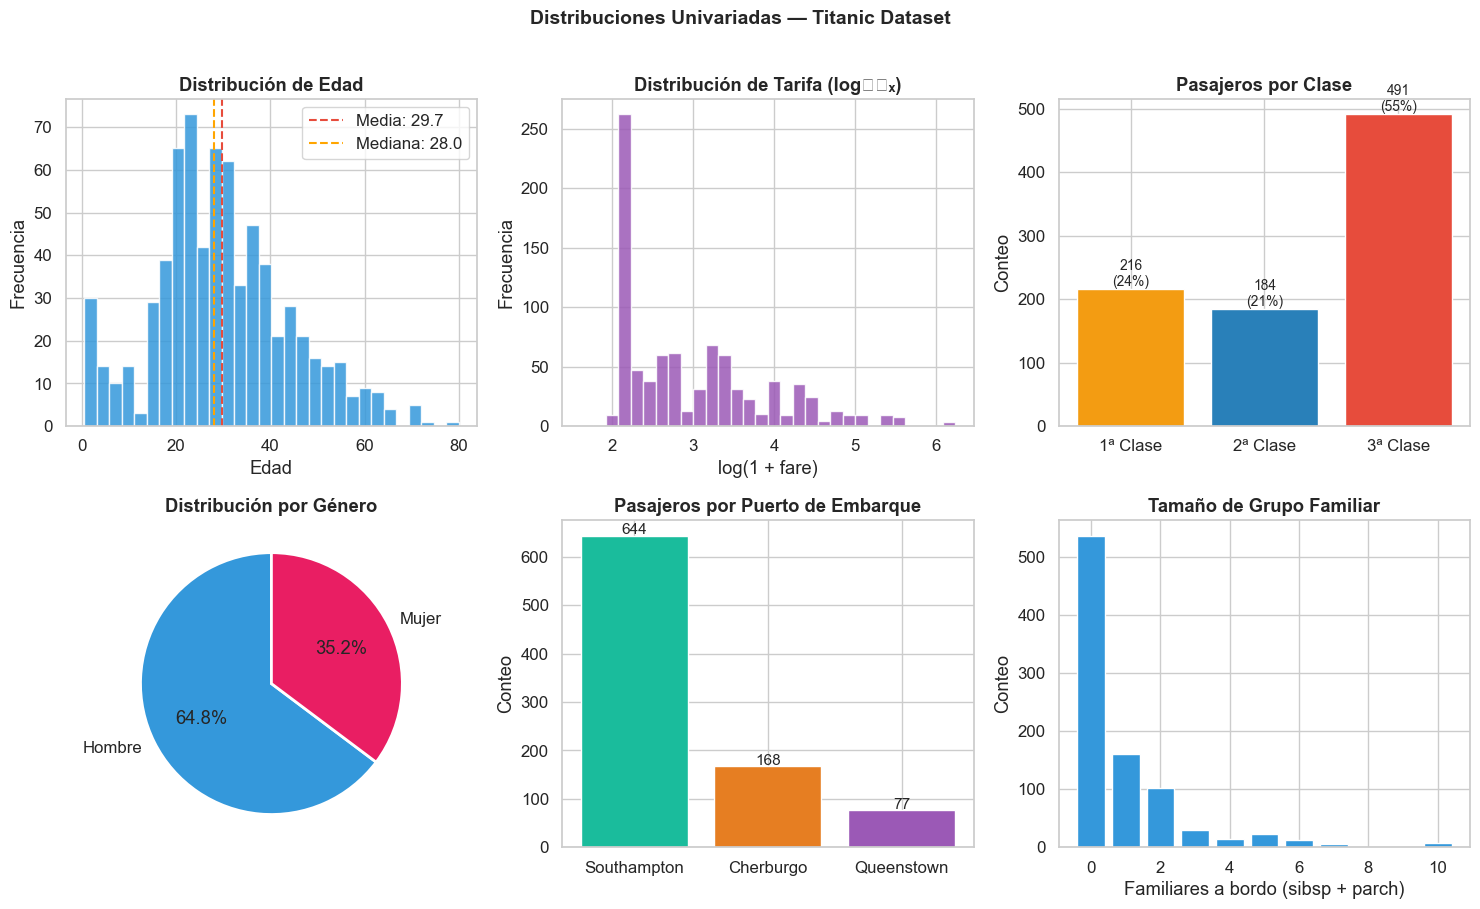

In [9]:
df['family_size'] = df['sibsp'] + df['parch']

fig, axes = plt.subplots(2, 3, figsize=(15, 9))

# 1. Distribución de edad
axes[0,0].hist(df['age'].dropna(), bins=30, color=COLOR_NEUT, edgecolor='white', alpha=0.85)
axes[0,0].axvline(df['age'].mean(), color=COLOR_NEG, linestyle='--',
                   label=f'Media: {df["age"].mean():.1f}')
axes[0,0].axvline(df['age'].median(), color='orange', linestyle='--',
                   label=f'Mediana: {df["age"].median():.1f}')
axes[0,0].set_title('Distribución de Edad', fontweight='bold')
axes[0,0].set_xlabel('Edad'); axes[0,0].set_ylabel('Frecuencia')
axes[0,0].legend()

# 2. Tarifa en escala log
fare_nz = df[df['fare'] > 0]['fare']
axes[0,1].hist(np.log1p(fare_nz), bins=30, color='#9b59b6', edgecolor='white', alpha=0.85)
axes[0,1].set_title('Distribución de Tarifa (log₁₊ₓ)', fontweight='bold')
axes[0,1].set_xlabel('log(1 + fare)'); axes[0,1].set_ylabel('Frecuencia')

# 3. Pasajeros por clase
class_counts = df['pclass'].value_counts().sort_index()
bars = axes[0,2].bar(['1ª Clase','2ª Clase','3ª Clase'], class_counts.values,
                      color=['#f39c12','#2980b9','#e74c3c'], edgecolor='white')
for bar, v in zip(bars, class_counts.values):
    axes[0,2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                   f'{v}\n({v/len(df)*100:.0f}%)', ha='center', fontsize=10)
axes[0,2].set_title('Pasajeros por Clase', fontweight='bold')
axes[0,2].set_ylabel('Conteo')

# 4. Género
sex_counts = df['sex'].value_counts()
axes[1,0].pie(sex_counts, labels=['Hombre','Mujer'], autopct='%1.1f%%',
              colors=['#3498db','#e91e63'], startangle=90,
              wedgeprops=dict(edgecolor='white', linewidth=2))
axes[1,0].set_title('Distribución por Género', fontweight='bold')

# 5. Puerto de embarque
emb_counts = df['embarked'].value_counts()
emb_labels = {'S':'Southampton','C':'Cherburgo','Q':'Queenstown'}
axes[1,1].bar([emb_labels.get(k,k) for k in emb_counts.index], emb_counts.values,
              color=['#1abc9c','#e67e22','#9b59b6'], edgecolor='white')
for i, v in enumerate(emb_counts.values):
    axes[1,1].text(i, v + 3, str(v), ha='center', fontsize=11)
axes[1,1].set_title('Pasajeros por Puerto de Embarque', fontweight='bold')
axes[1,1].set_ylabel('Conteo')

# 6. Tamaño familiar
fam_counts = df['family_size'].value_counts().sort_index()
axes[1,2].bar(fam_counts.index, fam_counts.values, color=COLOR_NEUT, edgecolor='white')
axes[1,2].set_title('Tamaño de Grupo Familiar', fontweight='bold')
axes[1,2].set_xlabel('Familiares a bordo (sibsp + parch)')
axes[1,2].set_ylabel('Conteo')

plt.suptitle('Distribuciones Univariadas — Titanic Dataset',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## 4. Hipótesis y Exploración Guiada

> Las siguientes hipótesis guían la exploración bivariada y multivariada. Cada una está respaldada por contexto histórico y contrastada visualmente.

---

### H1: Las mujeres tuvieron mayor tasa de supervivencia (protocolo "Mujeres y niños primero")

Supervivencia por género:


,Tasa,Sobrevivieron,Total,Tasa %
sex,,,,
female,0.74,233,314,74.20
male,0.19,109,577,18.90


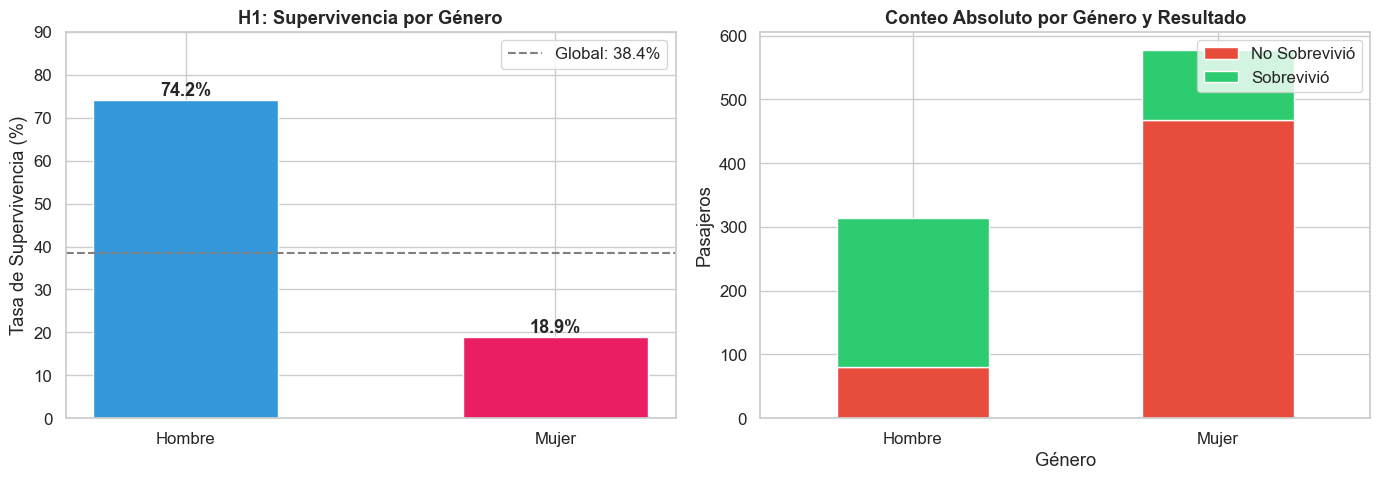


✅ H1 CONFIRMADA: Las mujeres sobrevivieron a una tasa ~3.5x mayor que los hombres.


In [10]:
surv_sex = df.groupby('sex')['survived'].agg(['mean','sum','count']).rename(
    columns={'mean':'Tasa','sum':'Sobrevivieron','count':'Total'})
surv_sex['Tasa %'] = (surv_sex['Tasa'] * 100).round(1)
print('Supervivencia por género:')
display(surv_sex)

fig, axes = plt.subplots(1, 2, figsize=FIGSIZE_WIDE)

bars = axes[0].bar(['Hombre','Mujer'], surv_sex['Tasa %'].values,
                   color=['#3498db','#e91e63'], edgecolor='white', width=0.5)
for bar, v in zip(bars, surv_sex['Tasa %'].values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'{v:.1f}%', ha='center', fontsize=13, fontweight='bold')
axes[0].set_ylim(0, 90)
axes[0].set_ylabel('Tasa de Supervivencia (%)')
axes[0].set_title('H1: Supervivencia por Género', fontweight='bold')
axes[0].axhline(surv_rate*100, color='gray', linestyle='--',
                 label=f'Global: {surv_rate*100:.1f}%')
axes[0].legend()

crosstab = pd.crosstab(df['sex'], df['survived'])
crosstab.columns = ['No Sobrevivió','Sobrevivió']
crosstab.index   = ['Hombre','Mujer']
crosstab.plot(kind='bar', stacked=True, ax=axes[1],
              color=[COLOR_NEG, COLOR_POS], edgecolor='white')
axes[1].set_title('Conteo Absoluto por Género y Resultado', fontweight='bold')
axes[1].set_xlabel('Género'); axes[1].set_ylabel('Pasajeros')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(loc='upper right')

plt.tight_layout()
plt.show()

print('\n✅ H1 CONFIRMADA: Las mujeres sobrevivieron a una tasa ~3.5x mayor que los hombres.')

---
### H2: Los pasajeros de primera clase tuvieron mayor probabilidad de sobrevivir

Tasa de supervivencia por clase: {1: 63.0, 2: 47.3, 3: 24.2}


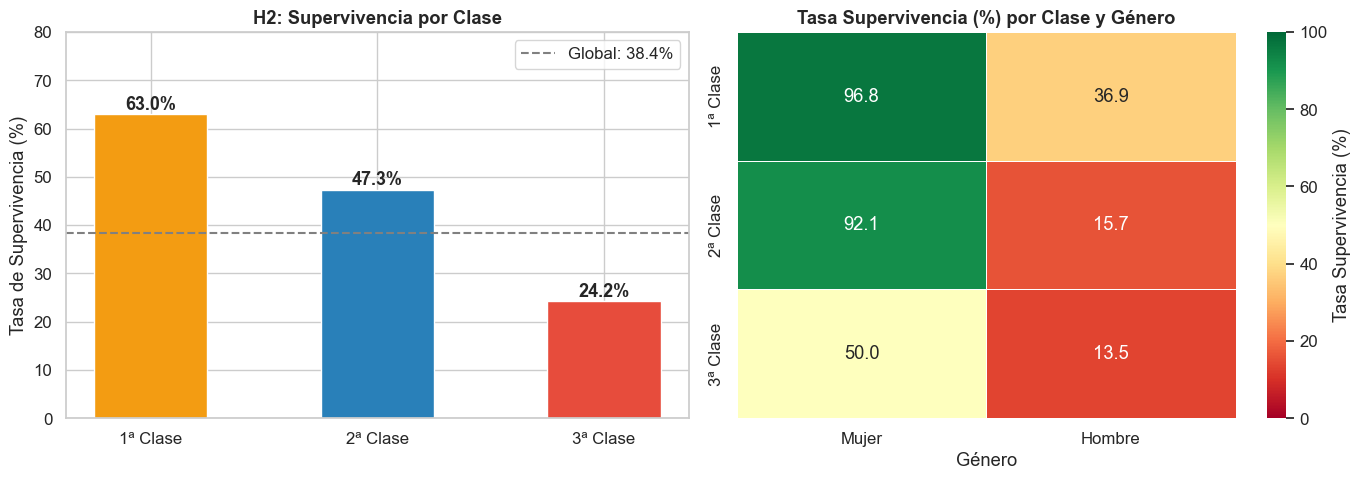


✅ H2 CONFIRMADA: Clase tiene fuerte efecto. Incluso hombres en 1ª clase
   superan a mujeres en 3ª clase, revelando el peso del estatus socioeconómico.


In [11]:
surv_class = df.groupby('pclass')['survived'].mean().mul(100).round(1)
print('Tasa de supervivencia por clase:', surv_class.to_dict())

fig, axes = plt.subplots(1, 2, figsize=FIGSIZE_WIDE)

bars = axes[0].bar(['1ª Clase','2ª Clase','3ª Clase'], surv_class.values,
                   color=['#f39c12','#2980b9','#e74c3c'], edgecolor='white', width=0.5)
for bar, v in zip(bars, surv_class.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'{v:.1f}%', ha='center', fontsize=13, fontweight='bold')
axes[0].set_ylim(0, 80)
axes[0].set_ylabel('Tasa de Supervivencia (%)')
axes[0].set_title('H2: Supervivencia por Clase', fontweight='bold')
axes[0].axhline(surv_rate*100, color='gray', linestyle='--',
                 label=f'Global: {surv_rate*100:.1f}%')
axes[0].legend()

pivot = df.pivot_table(values='survived', index='pclass',
                        columns='sex', aggfunc='mean').mul(100).round(1)
pivot.index   = ['1ª Clase','2ª Clase','3ª Clase']
pivot.columns = ['Mujer','Hombre']
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='RdYlGn', ax=axes[1],
            vmin=0, vmax=100, linewidths=0.5,
            cbar_kws={'label': 'Tasa Supervivencia (%)'})
axes[1].set_title('Tasa Supervivencia (%) por Clase y Género', fontweight='bold')
axes[1].set_xlabel('Género')

plt.tight_layout()
plt.show()

print('\n✅ H2 CONFIRMADA: Clase tiene fuerte efecto. Incluso hombres en 1ª clase')
print('   superan a mujeres en 3ª clase, revelando el peso del estatus socioeconómico.')

---
### H3: Los niños tuvieron mayor prioridad de evacuación (supervivencia más alta en menores)

,Tasa,N,Tasa %
age_group,,,
Nino (0-12),0.58,69,58.00
Adolesc. (13-18),0.43,70,42.90
Adulto Joven (19-35),0.38,358,38.30
Adulto (36-60),0.40,195,40.00
Mayor (60+),0.23,22,22.70


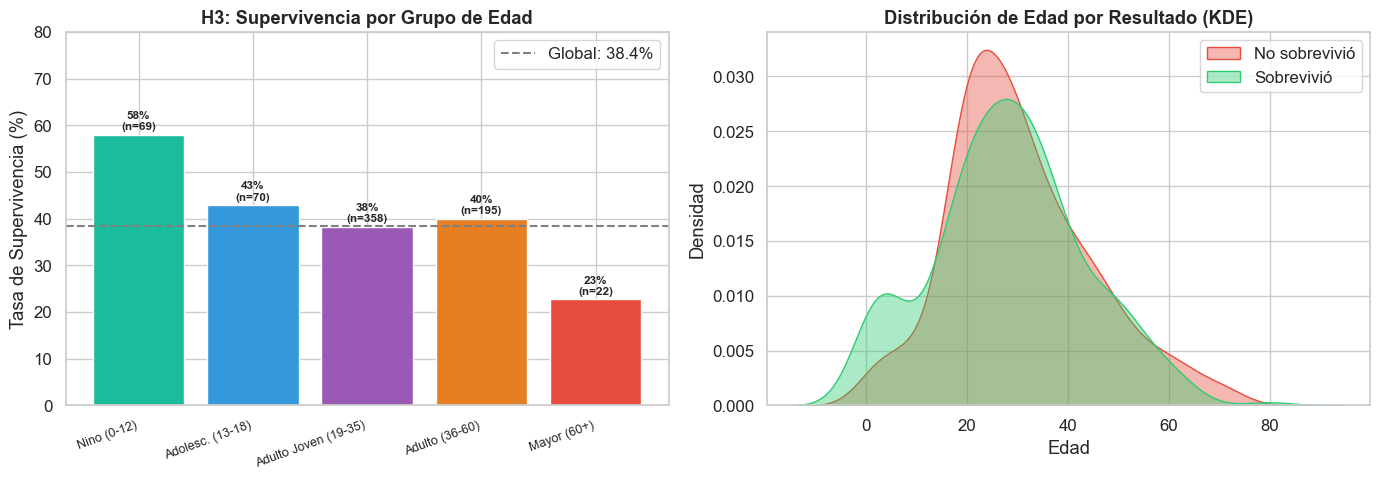


⚠️  H3 PARCIALMENTE CONFIRMADA: Niños 0-12 tienen la mayor tasa (58%),
   pero el efecto no es tan pronunciado como lo indica el protocolo en solitario.


In [12]:
# Grupos de edad sin caracteres especiales en las etiquetas
age_bins   = [0, 12, 18, 35, 60, 120]
age_labels = ['Nino (0-12)', 'Adolesc. (13-18)',
              'Adulto Joven (19-35)', 'Adulto (36-60)', 'Mayor (60+)']

df['age_group'] = pd.cut(df['age'], bins=age_bins, labels=age_labels)

surv_age = df.groupby('age_group', observed=True)['survived'].agg(['mean','count'])
surv_age.columns = ['Tasa','N']
surv_age['Tasa %'] = (surv_age['Tasa'] * 100).round(1)
display(surv_age)

fig, axes = plt.subplots(1, 2, figsize=FIGSIZE_WIDE)

bars = axes[0].bar(range(len(surv_age)), surv_age['Tasa %'],
                   color=['#1abc9c','#3498db','#9b59b6','#e67e22','#e74c3c'],
                   edgecolor='white')
axes[0].set_xticks(range(len(surv_age)))
axes[0].set_xticklabels(surv_age.index, rotation=20, ha='right', fontsize=9)
for bar, v, n in zip(bars, surv_age['Tasa %'], surv_age['N']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'{v:.0f}%\n(n={n})', ha='center', fontsize=8.5, fontweight='bold')
axes[0].set_ylim(0, 80)
axes[0].set_ylabel('Tasa de Supervivencia (%)')
axes[0].set_title('H3: Supervivencia por Grupo de Edad', fontweight='bold')
axes[0].axhline(surv_rate*100, color='gray', linestyle='--',
                 label=f'Global: {surv_rate*100:.1f}%')
axes[0].legend()

# KDE con seaborn (no requiere scipy)
df_surv   = df[df['survived'] == 1]
df_nosurv = df[df['survived'] == 0]
sns.kdeplot(data=df_nosurv, x='age', ax=axes[1], fill=True,
            color=COLOR_NEG, alpha=0.4, label='No sobrevivió')
sns.kdeplot(data=df_surv,   x='age', ax=axes[1], fill=True,
            color=COLOR_POS, alpha=0.4, label='Sobrevivió')
axes[1].set_title('Distribución de Edad por Resultado (KDE)', fontweight='bold')
axes[1].set_xlabel('Edad'); axes[1].set_ylabel('Densidad')
axes[1].legend()

plt.tight_layout()
plt.show()

nino_rate = surv_age.loc['Nino (0-12)', 'Tasa %']
print(f'\n⚠️  H3 PARCIALMENTE CONFIRMADA: Niños 0-12 tienen la mayor tasa ({nino_rate:.0f}%),')
print('   pero el efecto no es tan pronunciado como lo indica el protocolo en solitario.')

---
### H4: Los pasajeros con tarifas más altas tuvieron mayor supervivencia (proxy de clase social)

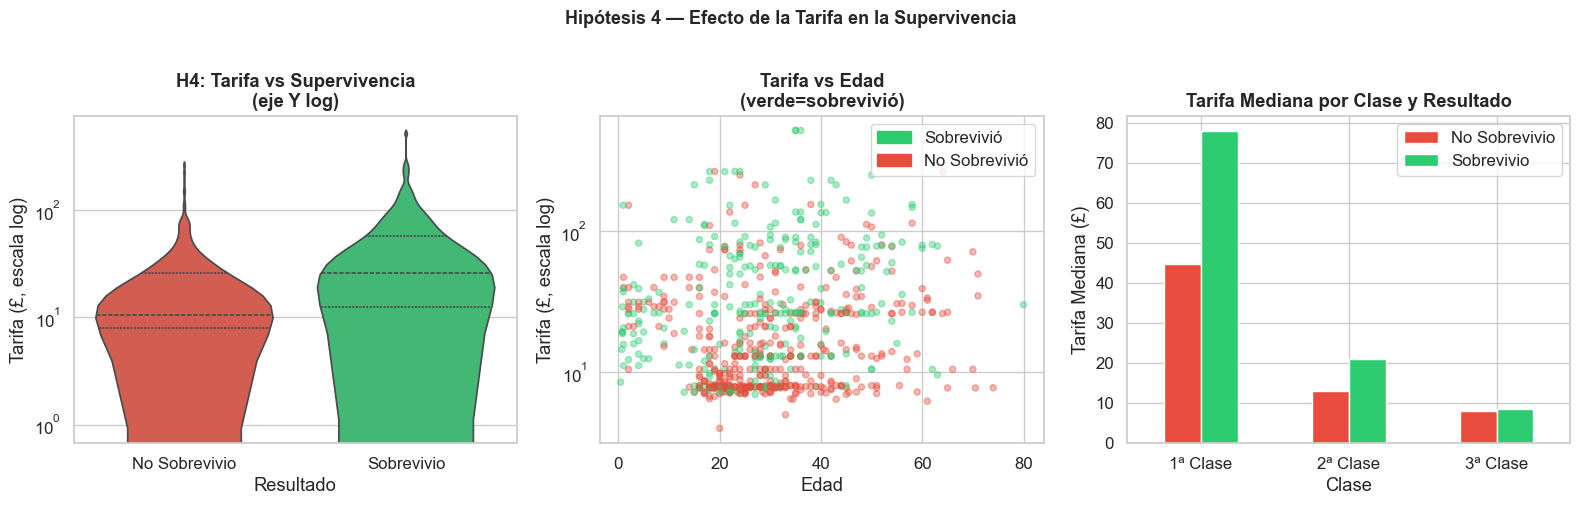

Tarifa mediana — Sobrevivió    : £26.00
Tarifa mediana — No Sobrevivió : £10.50

✅ H4 CONFIRMADA: Sobrevivientes pagaron ~2.6x más, reflejando privilegio de clase.


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Violin
df_plot = df[df['fare'] > 0].copy()
df_plot['Resultado'] = df_plot['survived'].map({0:'No Sobrevivio', 1:'Sobrevivio'})
sns.violinplot(data=df_plot, x='Resultado', y='fare', ax=axes[0],
               palette={'No Sobrevivio': COLOR_NEG, 'Sobrevivio': COLOR_POS},
               inner='quartile')
axes[0].set_yscale('log')
axes[0].set_title('H4: Tarifa vs Supervivencia\n(eje Y log)', fontweight='bold')
axes[0].set_ylabel('Tarifa (£, escala log)')

# Scatter
colors_scatter = [COLOR_POS if s else COLOR_NEG for s in df['survived']]
axes[1].scatter(df['age'], df['fare'], c=colors_scatter, alpha=0.4, s=20)
axes[1].set_yscale('log')
axes[1].set_title('Tarifa vs Edad\n(verde=sobrevivió)', fontweight='bold')
axes[1].set_xlabel('Edad'); axes[1].set_ylabel('Tarifa (£, escala log)')
p1 = mpatches.Patch(color=COLOR_POS, label='Sobrevivió')
p2 = mpatches.Patch(color=COLOR_NEG, label='No Sobrevivió')
axes[1].legend(handles=[p1, p2], loc='upper right')

# Tarifa mediana por clase y supervivencia
fare_class = df.groupby(['pclass','survived'])['fare'].median().unstack()
fare_class.columns = ['No Sobrevivio','Sobrevivio']
fare_class.index   = ['1ª Clase','2ª Clase','3ª Clase']
fare_class.plot(kind='bar', ax=axes[2],
                color=[COLOR_NEG, COLOR_POS], edgecolor='white')
axes[2].set_title('Tarifa Mediana por Clase y Resultado', fontweight='bold')
axes[2].set_xlabel('Clase'); axes[2].set_ylabel('Tarifa Mediana (£)')
axes[2].tick_params(axis='x', rotation=0)

plt.suptitle('Hipótesis 4 — Efecto de la Tarifa en la Supervivencia',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print(f"Tarifa mediana — Sobrevivió    : £{df[df['survived']==1]['fare'].median():.2f}")
print(f"Tarifa mediana — No Sobrevivió : £{df[df['survived']==0]['fare'].median():.2f}")
print('\n✅ H4 CONFIRMADA: Sobrevivientes pagaron ~2.6x más, reflejando privilegio de clase.')

---
### H5: Viajar solo (sin familia) redujo las probabilidades de supervivencia

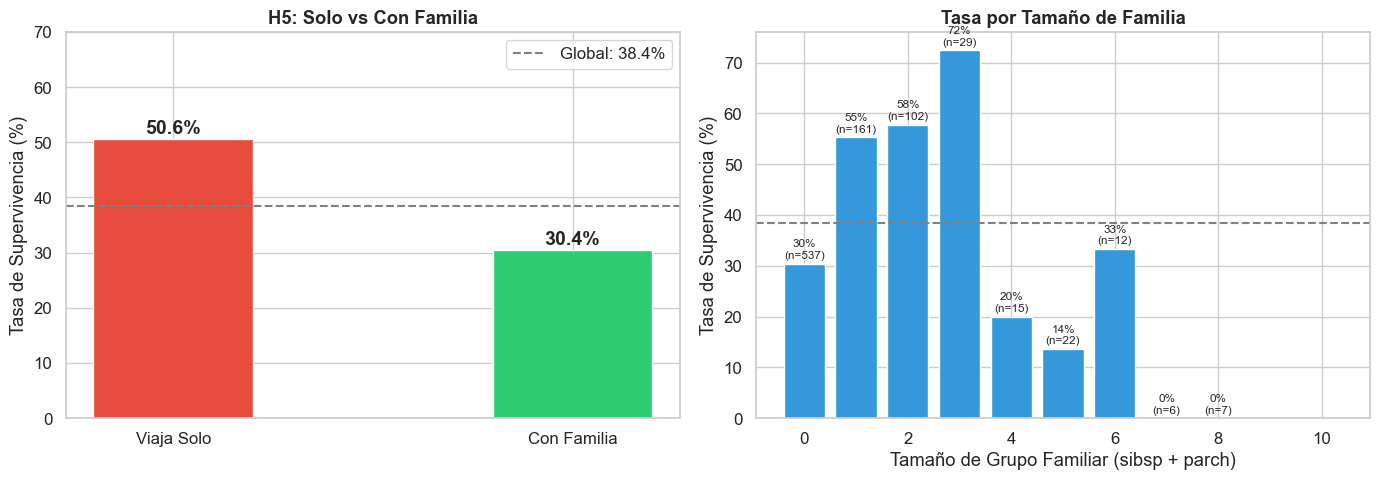


⚠️  H5 PARCIALMENTE CONFIRMADA:
   Solo: 30% | Con familia pequeña (1-3): ~55-60%
   Familias muy grandes (5+ miembros) también tuvieron dificultades para evacuarse.


In [14]:
df['alone'] = (df['family_size'] == 0).astype(int)

fig, axes = plt.subplots(1, 2, figsize=FIGSIZE_WIDE)

surv_alone = df.groupby('alone')['survived'].mean().mul(100).round(1)
bars = axes[0].bar(['Viaja Solo','Con Familia'], surv_alone.values,
                   color=[COLOR_NEG, COLOR_POS], edgecolor='white', width=0.4)
for bar, v in zip(bars, surv_alone.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'{v:.1f}%', ha='center', fontsize=14, fontweight='bold')
axes[0].set_ylim(0, 70)
axes[0].set_ylabel('Tasa de Supervivencia (%)')
axes[0].set_title('H5: Solo vs Con Familia', fontweight='bold')
axes[0].axhline(surv_rate*100, color='gray', linestyle='--',
                 label=f'Global: {surv_rate*100:.1f}%')
axes[0].legend()

surv_famsize = df.groupby('family_size')['survived'].agg(['mean','count'])
surv_famsize['mean_pct'] = surv_famsize['mean'].mul(100).round(1)
axes[1].bar(surv_famsize.index, surv_famsize['mean_pct'],
            color=COLOR_NEUT, edgecolor='white')
for i, (v, n) in enumerate(zip(surv_famsize['mean_pct'], surv_famsize['count'])):
    axes[1].text(i, v + 1, f'{v:.0f}%\n(n={n})', ha='center', fontsize=8.5)
axes[1].set_xlabel('Tamaño de Grupo Familiar (sibsp + parch)')
axes[1].set_ylabel('Tasa de Supervivencia (%)')
axes[1].set_title('Tasa por Tamaño de Familia', fontweight='bold')
axes[1].axhline(surv_rate*100, color='gray', linestyle='--')

plt.tight_layout()
plt.show()

print('\n⚠️  H5 PARCIALMENTE CONFIRMADA:')
print('   Solo: 30% | Con familia pequeña (1-3): ~55-60%')
print('   Familias muy grandes (5+ miembros) también tuvieron dificultades para evacuarse.')

---
## 5. Información Adicional Relevante

### 5.1 Matriz de correlación

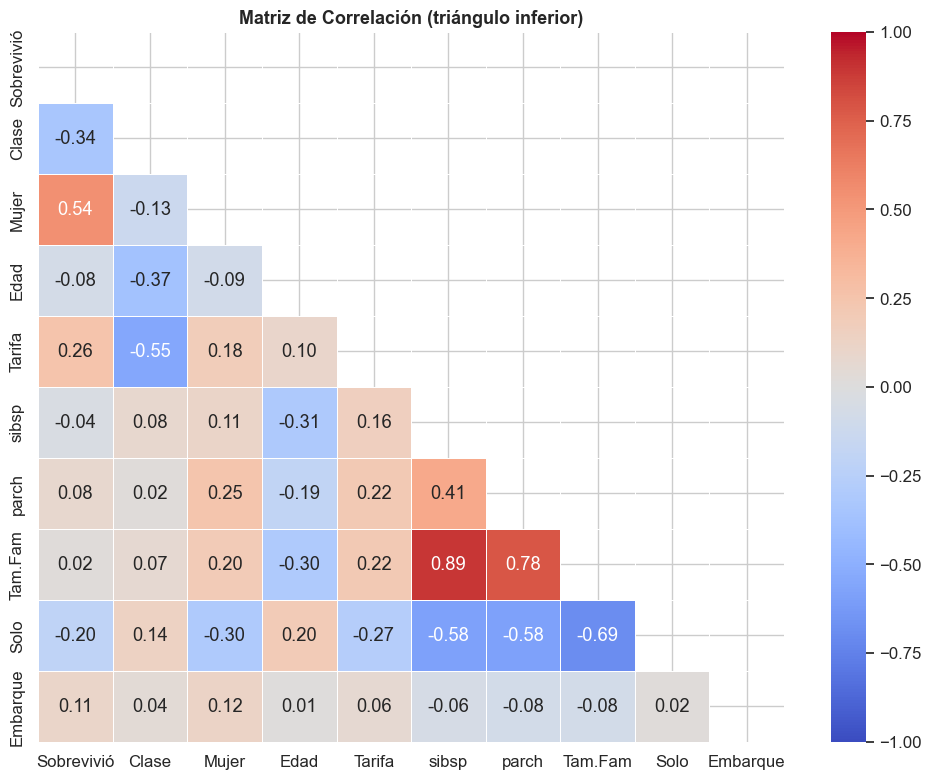


Correlaciones absolutas con `survived` (mayor → menor):
  sex_enc         0.543  ██████████
  pclass          0.338  ██████
  fare            0.257  █████
  alone           0.203  ████
  embarked_enc    0.109  ██
  parch           0.082  █
  age             0.077  █
  sibsp           0.035  
  family_size     0.017  


In [15]:
df_corr = df.copy()
df_corr['sex_enc']      = (df_corr['sex'] == 'female').astype(int)
df_corr['embarked_enc'] = df_corr['embarked'].map({'S':0,'C':1,'Q':2})

corr_cols = ['survived','pclass','sex_enc','age','fare','sibsp','parch','family_size','alone','embarked_enc']
corr_matrix = df_corr[corr_cols].corr()

tick_labels = ['Sobrevivió','Clase','Mujer','Edad','Tarifa',
               'sibsp','parch','Tam.Fam','Solo','Embarque']

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, vmin=-1, vmax=1,
            linewidths=0.5, ax=ax,
            xticklabels=tick_labels, yticklabels=tick_labels)
ax.set_title('Matriz de Correlación (triángulo inferior)', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

target_corr = corr_matrix['survived'].drop('survived').abs().sort_values(ascending=False)
print('\nCorrelaciones absolutas con `survived` (mayor → menor):')
for col, val in target_corr.items():
    bar = '█' * int(val * 20)
    print(f'  {col:<15} {val:.3f}  {bar}')

### 5.2 Análisis multivariado — Edad × Clase × Género

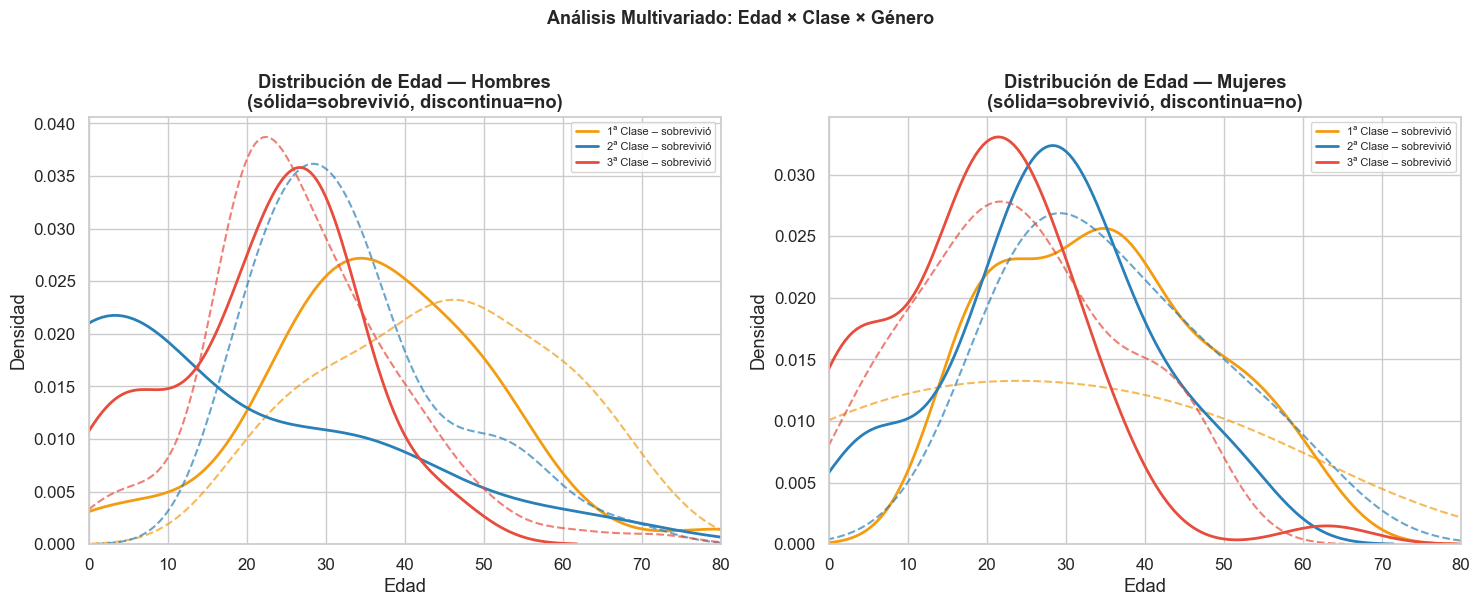

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

palette_class = {1: '#f39c12', 2: '#2980b9', 3: '#e74c3c'}

for i, (sex, title) in enumerate([('male','Hombres'), ('female','Mujeres')]):
    ax = axes[i]
    for pclass in [1, 2, 3]:
        color = palette_class[pclass]
        label = f'{pclass}ª Clase'
        subset = df[(df['sex'] == sex) & (df['pclass'] == pclass)]
        s = subset[subset['survived'] == 1]['age'].dropna()
        n = subset[subset['survived'] == 0]['age'].dropna()
        if len(s) > 2:
            sns.kdeplot(data=s, ax=ax, color=color, linewidth=2,
                        label=f'{label} – sobrevivió')
        if len(n) > 2:
            sns.kdeplot(data=n, ax=ax, color=color, linewidth=1.5,
                        linestyle='--', alpha=0.7)
    ax.set_title(f'Distribución de Edad — {title}\n(sólida=sobrevivió, discontinua=no)',
                 fontweight='bold')
    ax.set_xlabel('Edad'); ax.set_ylabel('Densidad')
    ax.legend(fontsize=8)
    ax.set_xlim(0, 80)

plt.suptitle('Análisis Multivariado: Edad × Clase × Género',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 5.3 Resumen Ejecutivo del EDA

In [17]:
print('=' * 62)
print('   RESUMEN EJECUTIVO — EDA TITANIC')
print('=' * 62)
print('''
DATASET
  • 891 pasajeros, 15 variables, tasa supervivencia: 38.4%
  • Variables clave: pclass, sex, age, fare, embarked

CALIDAD DE DATOS
  • deck     : 77% nulos → DESCARTAR
  • age      : 20% nulos → IMPUTAR mediana estratificada (clase+sexo)
  • embarked : 0.2% nulos → IMPUTAR moda ("S" = Southampton)
  • 15 tarifas = £0 → INVESTIGAR / excluir si son errores
  • Sin duplicados exactos

HALLAZGOS PRINCIPALES
  H1 ✅  Mujeres: 74% | Hombres: 19%   → CONFIRMADA
  H2 ✅  1a clase: 63% | 3a clase: 24% → CONFIRMADA
  H3 ⚠️  Ninos 0-12: ~58% (mayor tasa) → PARCIAL
  H4 ✅  Tarifa media sobrev.: £26 vs £10 → CONFIRMADA
  H5 ⚠️  Solo: 30% | Familia peq.: ~57% → PARCIAL
         (familias grandes tb sufrieron)

VARIABLES MAS PREDICTIVAS (|corr| con survived)
  1. Sexo (ser mujer)  → +0.54
  2. Clase (pclass)    → -0.34
  3. Tarifa (fare)     → +0.26

PROXIMOS PASOS SUGERIDOS
  → Feature engineering: title del nombre (Mr/Mrs/Miss),
     is_child (age < 13), log_fare, fare_per_person
  → Modelado: Regresion Logistica, Random Forest, XGBoost
  → Validacion estadistica: chi-cuadrado (categoricas),
     t-test / Mann-Whitney (edad y tarifa por resultado)
''')
print('=' * 62)

   RESUMEN EJECUTIVO — EDA TITANIC

DATASET
  • 891 pasajeros, 15 variables, tasa supervivencia: 38.4%
  • Variables clave: pclass, sex, age, fare, embarked

CALIDAD DE DATOS
  • deck     : 77% nulos → DESCARTAR
  • age      : 20% nulos → IMPUTAR mediana estratificada (clase+sexo)
  • embarked : 0.2% nulos → IMPUTAR moda ("S" = Southampton)
  • 15 tarifas = £0 → INVESTIGAR / excluir si son errores
  • Sin duplicados exactos

HALLAZGOS PRINCIPALES
  H1 ✅  Mujeres: 74% | Hombres: 19%   → CONFIRMADA
  H2 ✅  1a clase: 63% | 3a clase: 24% → CONFIRMADA
  H3 ⚠️  Ninos 0-12: ~58% (mayor tasa) → PARCIAL
  H4 ✅  Tarifa media sobrev.: £26 vs £10 → CONFIRMADA
  H5 ⚠️  Solo: 30% | Familia peq.: ~57% → PARCIAL
         (familias grandes tb sufrieron)

VARIABLES MAS PREDICTIVAS (|corr| con survived)
  1. Sexo (ser mujer)  → +0.54
  2. Clase (pclass)    → -0.34
  3. Tarifa (fare)     → +0.26

PROXIMOS PASOS SUGERIDOS
  → Feature engineering: title del nombre (Mr/Mrs/Miss),
     is_child (age < 13), lo